REF:

https://blog.paperspace.com/beginners-guide-to-boltzmann-machines-pytorch/

In [1]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
from datasets import load_dataset
# for saving
import matplotlib.pyplot as plt

In [4]:
## set runtime, needs the gpu to run
if torch.backends.mps.is_available():
  device = torch.device("mps")
  x = torch.ones(1, device=device)
  print (x)
elif torch.backends.cuda.is_built():
  device = torch.device("cuda")
  x = torch.ones(1, device=device)
  print (x)
else:
  print ("GPU not found.")

tensor([1.], device='mps:0')


In [5]:
### DATA 

dataset = load_dataset("mnist")

# if using colab
# dataset = load_dataset("ylecun/mnist")
# data preprocessing

# convert  Image to Tensor, flatten (28x28 -> 784), and binarize
# RBMs require binary visible inputs

transform = transforms.ToTensor()

def preprocess_images(batch):
    # keep native image shape: [1, 28, 28] per image (channel-first, unflattened)
    imgs = [transform(img) for img in batch["image"]]
    imgs = torch.stack(imgs)  # -> [batch_size, 1, 28, 28]
    batch["image"] = imgs
    return batch

train_dataset = dataset["train"].with_transform(preprocess_images)
test_dataset = dataset["test"].with_transform(preprocess_images)

In [6]:
### MODEL

class CNNModel(nn.Module):
    """Two-layer CNN for MNIST digit classification."""

    def __init__(self):
        super(CNNModel, self).__init__()

        # Convolution 1
        self.cnn1 = nn.Conv2d(in_channels=1, out_channels=16, kernel_size=5, stride=1, padding=0)
        self.relu1 = nn.ReLU()

        # Max pool 1
        self.maxpool1 = nn.MaxPool2d(kernel_size=2)

        # Convolution 2
        self.cnn2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=5, stride=1, padding=0)
        self.relu2 = nn.ReLU()

        # Max pool 2
        self.maxpool2 = nn.MaxPool2d(kernel_size=2)

        # Fully connected 1 (readout)
        self.fc1 = nn.Linear(32 * 4 * 4, 10)

    def forward(self, x):
        # Convolution 1
        out = self.cnn1(x)
        out = self.relu1(out)

        # Max pool 1
        out = self.maxpool1(out)

        # Convolution 2
        out = self.cnn2(out)
        out = self.relu2(out)

        # Max pool 2
        out = self.maxpool2(out)

        # Reshape: (batch, 32, 4, 4) → (batch, 512)
        out = out.view(out.size(0), -1)

        # Linear function (readout)
        out = self.fc1(out)

        return out

In [ ]:
### EVAL

def evaluate(model, test_loader, device):
    """Evaluate model accuracy on the test set."""
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for idx, batch in enumerate(test_loader):
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100.0 * correct / total

In [8]:
### INIT MODEL/DATA_LOADER/HYPERPARAMS

batch_size = 100
n_iters = 10000
learning_rate = 0.01

model = CNNModel().to(device)

num_epochs = int(n_iters / (len(train_dataset) / batch_size))

# PyTorch dataLoader for training and test sets
train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset, batch_size=batch_size, shuffle=True
    )
test_loader = torch.utils.data.DataLoader(
    dataset=test_dataset, batch_size=batch_size, shuffle=False
    )

In [9]:
### EPOCHS LOOP

def train(model, train_loader, test_loader, num_epochs, learning_rate, device):
    """Train the CNN and evaluate every 500 iterations."""
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

    iter_count = 0
    for epoch in range(num_epochs):
        model.train()
        for idx, batch in enumerate(train_loader):
            images = batch['image'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            iter_count += 1

            if iter_count % 500 == 0:
                accuracy = evaluate(model, test_loader, device)
                print(
                    f"Iteration: {iter_count}. Loss: {loss.item():.4f}. "
                    f"Accuracy: {accuracy:.2f}%"
                )

train(model, train_loader, test_loader, num_epochs, learning_rate, device)

Iteration: 500. Loss: 0.3315. Accuracy: 90.10%
Iteration: 1000. Loss: 0.2744. Accuracy: 93.59%
Iteration: 1500. Loss: 0.1331. Accuracy: 94.81%
Iteration: 2000. Loss: 0.1111. Accuracy: 95.73%
Iteration: 2500. Loss: 0.1639. Accuracy: 96.48%
Iteration: 3000. Loss: 0.1438. Accuracy: 96.79%
Iteration: 3500. Loss: 0.1692. Accuracy: 97.00%
Iteration: 4000. Loss: 0.0757. Accuracy: 97.27%
Iteration: 4500. Loss: 0.1505. Accuracy: 97.54%
Iteration: 5000. Loss: 0.0705. Accuracy: 97.72%
Iteration: 5500. Loss: 0.0933. Accuracy: 97.47%
Iteration: 6000. Loss: 0.0705. Accuracy: 97.64%
Iteration: 6500. Loss: 0.0282. Accuracy: 98.04%
Iteration: 7000. Loss: 0.0573. Accuracy: 98.10%
Iteration: 7500. Loss: 0.0558. Accuracy: 98.13%
Iteration: 8000. Loss: 0.0859. Accuracy: 98.08%
Iteration: 8500. Loss: 0.0401. Accuracy: 98.18%
Iteration: 9000. Loss: 0.0600. Accuracy: 98.26%
Iteration: 9500. Loss: 0.0117. Accuracy: 98.36%


In [26]:
def save_model(model, path="cnn_mnist.pt"):
    """Save model weights to local storage."""
    torch.save(model.state_dict(), path)
    print(f"Model saved to {path}")


def load_model(path="cnn_mnist.pt", device=device):
    """Load model weights into a fresh CNNModel instance."""
    model = CNNModel().to(device)
    model.load_state_dict(torch.load(path, map_location=device))
    model.eval()
    print(f"Model loaded from {path}")
    return model

In [27]:
DIR = 'classification_models/'
FILE_NAME = 'eval_classification_model_cnn.pt'
PATH = DIR + FILE_NAME

save_model(model, path=PATH)

classification_model_1 = load_model(path=PATH)

Model saved to classification_models/eval_classification_model_cnn.pt
Model loaded from classification_models/eval_classification_model_cnn.pt


In [12]:
def get_classification_distribution(model, images, device, num_classes=10):
    """
    Run the model on a batch of N images and return the distribution
    of predicted classes.

    Returns:
        counts: dict {class_label: raw count}
        fractions: dict {class_label: count / N}
        N: total number of images
    """
    model.eval()
    images = images.to(device)
    N = images.size(0)

    with torch.no_grad():
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

    counts = {c: 0 for c in range(num_classes)}
    for p in predicted.tolist():
        counts[p] += 1

    fractions = {c: counts[c] / N for c in range(num_classes)}
    return counts, fractions, N

In [13]:
def plot_distribution_histogram(counts, N, title="Predicted Class Distribution"):
    """Bar chart of class counts."""
    classes = sorted(counts.keys())
    values = [counts[c] for c in classes]

    plt.figure(figsize=(8, 4))
    plt.bar(classes, values, color="steelblue")
    plt.xticks(classes)
    plt.xlabel("Class")
    plt.ylabel(f"Count (out of {N})")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def build_compact_distribution_string(counts, N):
    """
    Compact one-row 'table' string, e.g.:
    0:12/100 | 1:9/100 | 2:11/100 | 3:8/100 | ...
    """
    return " | ".join(f"{c}:{counts[c]}/{N}" for c in sorted(counts))

0:15/100 | 1:12/100 | 2:13/100 | 3:3/100 | 4:9/100 | 5:10/100 | 6:8/100 | 7:10/100 | 8:11/100 | 9:9/100


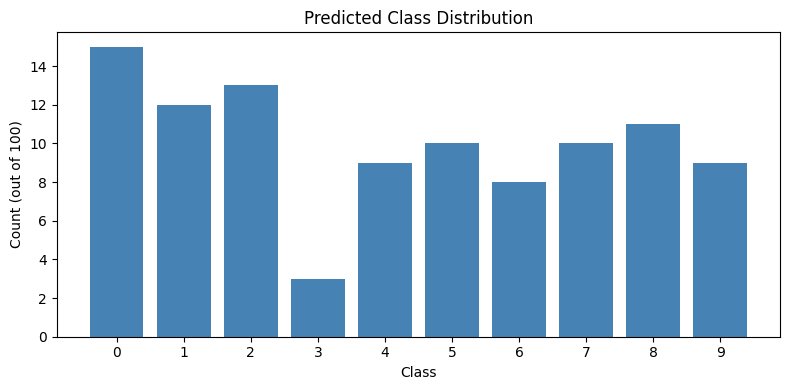

In [25]:
### test plotting

# grab a sample of N images from the test set
sample_batch = next(iter(train_loader))
sample_images = sample_batch["image"][:100]  # N = 50

counts, fractions, N = get_classification_distribution(classification_model_1, sample_images, device)

print(build_compact_distribution_string(counts, N))
# e.g. 0:6/50 | 1:4/50 | 2:5/50 | 3:5/50 | 4:6/50 | 5:4/50 | 6:5/50 | 7:5/50 | 8:5/50 | 9:5/50

plot_distribution_histogram(counts, N)

fin